# VGG-16-BN on ImageNet-100 with Fine-Grained Pruning and Power-of-Two PTQ

This notebook trains a VGG-16-BN model on ImageNet-100, applies unstructured fine-grained pruning, performs post-training quantization with power-of-two scales, and exports the pruned FP32 model for TVM experiments.


## Environment Setup

Common imports, reproducibility settings, and output directories. All generated artifacts are written under `./weights/`, `./plots/`, and `./exports/`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/AOC/final

/content/drive/MyDrive/AOC/final


In [ ]:
import os
import math
import copy
import time
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import torch.ao.quantization as tq
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import LambdaLR

try:
    from torchsummary import summary
except Exception:
    summary = None

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
NUM_CLASSES = 100
INPUT_SIZE = 224
DEFAULT_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_DIR = Path("./weights")
PLOTS_DIR = Path("./plots")
EXPORTS_DIR = Path("./exports")
for directory in (WEIGHTS_DIR, PLOTS_DIR, EXPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = WEIGHTS_DIR / "best_vgg16_imagenet100_pruned_ready.pth"
PRUNED_FP32_PATH = WEIGHTS_DIR / "vgg16_imagenet100_pruned_fp32.pth"
PTQ_INT8_PATH = WEIGHTS_DIR / "vgg16_imagenet100_pruned_power2_int8.pth"


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
print("PyTorch version:", torch.__version__)
print("Using device:", DEFAULT_DEVICE)


PyTorch version: 2.10.0+cu128
Using device: cuda


## Dataset

ImageNet-100 is downloaded with KaggleHub and loaded with `torchvision.datasets.ImageFolder`. The loader expects ImageNet-style class folders and automatically handles common `train`/`val`/`test` folder layouts. Images are resized/cropped to `224x224` and normalized with standard ImageNet statistics.


In [ ]:
IMAGENET100_KAGGLE_ID = "ambityga/imagenet100"
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def download_imagenet100(data_root: Optional[str] = None) -> Path:
    """Return a local ImageNet-100 root path, downloading from KaggleHub when needed."""
    if data_root is not None:
        root = Path(data_root).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"Provided ImageNet-100 path does not exist: {root}")
        return root

    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "kagglehub is required to download ambityga/imagenet100. "
            "Install it or pass data_root to get_imagenet100_loaders(...)."
        ) from exc

    root = Path(kagglehub.dataset_download(IMAGENET100_KAGGLE_ID)).resolve()
    print("Path to ImageNet-100 dataset files:", root)
    return root


def _has_image_file(directory: Path) -> bool:
    try:
        for item in directory.rglob("*"):
            if item.is_file() and item.suffix.lower() in IMG_EXTENSIONS:
                return True
    except PermissionError:
        return False
    return False


def _is_imagefolder_split(directory: Path) -> bool:
    """True when directory looks like an ImageFolder split: split/class_name/images."""
    if not directory.is_dir():
        return False
    class_dirs = [child for child in directory.iterdir() if child.is_dir()]
    if len(class_dirs) < 2:
        return False
    return any(_has_image_file(class_dir) for class_dir in class_dirs[: min(len(class_dirs), 20)])


def _discover_imagefolder_splits(root: Path, max_depth: int = 4) -> Dict[str, List[Path]]:
    candidates = [root]
    for current, dirs, _ in os.walk(root):
        current_path = Path(current)
        depth = len(current_path.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        candidates.append(current_path)

    split_dirs: Dict[str, List[Path]] = {"train": [], "val": [], "test": [], "single": []}
    for candidate in sorted(set(candidates), key=lambda p: (len(p.parts), str(p))):
        if not _is_imagefolder_split(candidate):
            continue
        name = candidate.name.lower()
        if name.startswith("train") or name in {"training", "ilsvrc2012_img_train"}:
            split_dirs["train"].append(candidate)
        elif name.startswith(("val", "valid")) or name in {"validation", "ilsvrc2012_img_val"}:
            split_dirs["val"].append(candidate)
        elif name.startswith("test"):
            split_dirs["test"].append(candidate)
        else:
            split_dirs["single"].append(candidate)

    for key in split_dirs:
        deduped = []
        for item in split_dirs[key]:
            if not any(str(item).startswith(str(parent) + os.sep) for parent in deduped):
                deduped.append(item)
        split_dirs[key] = deduped
    return split_dirs


class RemappedImageFolder(Dataset):
    """Wrap ImageFolder and remap local class indices into a shared global class list."""

    def __init__(self, dataset: datasets.ImageFolder, classes: Sequence[str]) -> None:
        self.dataset = dataset
        self.classes = list(classes)
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}
        self._target_remap = [self.class_to_idx[class_name] for class_name in dataset.classes]

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int):
        image, target = self.dataset[index]
        return image, self._target_remap[target]


def _make_imagefolder_dataset(paths: Sequence[Path], transform) -> Dataset:
    if len(paths) == 0:
        raise ValueError("No ImageFolder paths were provided.")
    datasets_list = [datasets.ImageFolder(str(path), transform=transform) for path in paths]
    if len(datasets_list) == 1:
        return datasets_list[0]
    global_classes = sorted({class_name for dataset in datasets_list for class_name in dataset.classes})
    remapped = [RemappedImageFolder(dataset, global_classes) for dataset in datasets_list]
    return ConcatDataset(remapped)


def _dataset_classes(dataset: Dataset) -> List[str]:
    if hasattr(dataset, "classes"):
        return dataset.classes
    if isinstance(dataset, ConcatDataset) and len(dataset.datasets) > 0:
        return _dataset_classes(dataset.datasets[0])
    if isinstance(dataset, Subset):
        return _dataset_classes(dataset.dataset)
    return []


def _split_dataset_indices(length: int, ratios: Tuple[float, ...], seed: int = SEED) -> List[List[int]]:
    if not math.isclose(sum(ratios), 1.0, rel_tol=1e-6, abs_tol=1e-6):
        raise ValueError("Split ratios must sum to 1.0")
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(length, generator=generator).tolist()
    counts = [int(length * ratio) for ratio in ratios[:-1]]
    counts.append(length - sum(counts))
    splits = []
    offset = 0
    for count in counts:
        splits.append(indices[offset : offset + count])
        offset += count
    return splits


def get_imagenet100_loaders(
    batch_size: int = 64,
    data_root: Optional[str] = None,
    split_ratio: float = 0.1,
    num_workers: Optional[int] = None,
    seed: int = SEED,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Create train/val/test loaders for the KaggleHub ImageNet-100 dataset."""
    root = download_imagenet100(data_root)
    split_dirs = _discover_imagefolder_splits(root)

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(INPUT_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), value="random"),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    if split_dirs["train"]:
        train_full = _make_imagefolder_dataset(split_dirs["train"], train_transform)
        train_full_eval = _make_imagefolder_dataset(split_dirs["train"], eval_transform)

        if split_dirs["val"]:
            train_set = train_full
            val_set = _make_imagefolder_dataset(split_dirs["val"], eval_transform)
        else:
            train_idx, val_idx = _split_dataset_indices(len(train_full), (1.0 - split_ratio, split_ratio), seed)
            train_set = Subset(train_full, train_idx)
            val_set = Subset(train_full_eval, val_idx)

        if split_dirs["test"]:
            test_set = _make_imagefolder_dataset(split_dirs["test"], eval_transform)
        else:
            print("ImageNet-100 test split not found; using validation split as test set.")
            test_set = val_set
    elif split_dirs["single"]:
        single_train = _make_imagefolder_dataset([split_dirs["single"][0]], train_transform)
        single_eval = _make_imagefolder_dataset([split_dirs["single"][0]], eval_transform)
        train_idx, val_idx, test_idx = _split_dataset_indices(
            len(single_train), (1.0 - 2 * split_ratio, split_ratio, split_ratio), seed
        )
        train_set = Subset(single_train, train_idx)
        val_set = Subset(single_eval, val_idx)
        test_set = Subset(single_eval, test_idx)
    else:
        raise FileNotFoundError(
            f"Could not find ImageFolder-compatible ImageNet-100 train/val/test folders under {root}"
        )

    if num_workers is None:
        num_workers = min(8, os.cpu_count() or 2)
    loader_kwargs = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=num_workers > 0,
    )

    train_loader = DataLoader(train_set, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_set, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_set, shuffle=False, **loader_kwargs)

    sample_image, sample_label = train_set[0]
    class_names = _dataset_classes(train_set)
    print(
        f"ImageNet-100: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}, "
        f"classes={len(class_names) or 'unknown'}, sample_shape={tuple(sample_image.shape)}, sample_label={sample_label}"
    )
    return train_loader, val_loader, test_loader


BATCH_SIZE = 64
VAL_TRAIN_SPLIT_RATIO = 0.1
NUM_WORKERS = min(8, os.cpu_count() or 2)

train_loader, val_loader, test_loader = get_imagenet100_loaders(
    batch_size=BATCH_SIZE,
    split_ratio=VAL_TRAIN_SPLIT_RATIO,
    num_workers=NUM_WORKERS,
)
class_names = _dataset_classes(train_loader.dataset)


Using Colab cache for faster access to the 'imagenet100' dataset.
Path to ImageNet-100 dataset files: /kaggle/input/imagenet100
ImageNet-100 test split not found; using validation split as test set.
ImageNet-100: train=130000, val=5000, test=5000, classes=100, sample_shape=(3, 224, 224), sample_label=0


## VGG-16-BN Model

The model is a true VGG-16-BN feature extractor with 13 convolution layers and a compact `AdaptiveAvgPool2d((1, 1)) + Linear(512, 100)` classifier. This keeps the model practical for pruning, quantization, and future TVM hardware tests while preserving the VGG-16 block structure.


In [ ]:
class VGG16BN(nn.Module):
    """VGG-16-BN for 224x224 ImageNet-100 with eager-mode quantization stubs."""

    def __init__(self, in_channels: int = 3, num_classes: int = NUM_CLASSES) -> None:
        super().__init__()
        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)
        self._initialize_weights()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.quant(x)
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        x = self.dequant(x)
        return x

    def fuse_model(self) -> None:
        """Fuse Conv-BN-ReLU modules before static quantization."""
        for idx in range(len(self.features) - 2):
            if (
                isinstance(self.features[idx], nn.Conv2d)
                and isinstance(self.features[idx + 1], nn.BatchNorm2d)
                and isinstance(self.features[idx + 2], nn.ReLU)
            ):
                tq.fuse_modules(self.features, [str(idx), str(idx + 1), str(idx + 2)], inplace=True)

    def _initialize_weights(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, 0, 0.01)
                nn.init.zeros_(module.bias)


VGG = VGG16BN

model = VGG16BN(num_classes=NUM_CLASSES)
if summary is not None:
    summary(model, (3, INPUT_SIZE, INPUT_SIZE), device="cpu")
else:
    print(model)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         QuantStub-1          [-1, 3, 224, 224]               0
            Conv2d-2         [-1, 64, 224, 224]           1,728
       BatchNorm2d-3         [-1, 64, 224, 224]             128
              ReLU-4         [-1, 64, 224, 224]               0
            Conv2d-5         [-1, 64, 224, 224]          36,864
       BatchNorm2d-6         [-1, 64, 224, 224]             128
              ReLU-7         [-1, 64, 224, 224]               0
         MaxPool2d-8         [-1, 64, 112, 112]               0
            Conv2d-9        [-1, 128, 112, 112]          73,728
      BatchNorm2d-10        [-1, 128, 112, 112]             256
             ReLU-11        [-1, 128, 112, 112]               0
           Conv2d-12        [-1, 128, 112, 112]         147,456
      BatchNorm2d-13        [-1, 128, 112, 112]             256
             ReLU-14        [-1, 128, 1

## Training with Individual Weight L1 Regularization

Training uses SGD with momentum, weight decay, label smoothing, and a cosine schedule with warmup. `LAMBDA` now controls optional L1 regularization on individual Conv2d and Linear weights, which encourages fine-grained unstructured pruning by making individual weights smaller before magnitude pruning. Useful `LAMBDA` trial values are `0`, `1e-7`, `5e-7`, `1e-6`, `5e-6`, and `1e-5`.


In [ ]:
def preprocess_filename(filename: str, existed: str = "keep_both") -> str:
    path = Path(filename)
    if existed == "overwrite":
        return str(path)
    if existed == "keep_both":
        base = path.with_suffix("")
        suffix = path.suffix
        candidate = path
        count = 1
        while candidate.exists():
            candidate = Path(f"{base}-{count}{suffix}")
            count += 1
        return str(candidate)
    if existed == "raise" and path.exists():
        raise FileExistsError(f"{path} already exists.")
    if existed == "raise":
        return str(path)
    raise ValueError(f"Unknown value for existed: {existed}")


def save_model(model: nn.Module, filename: str, verbose: bool = True, existed: str = "overwrite") -> str:
    filename = preprocess_filename(filename, existed)
    Path(filename).parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), filename)
    if verbose:
        print(f"Model saved at {filename} ({Path(filename).stat().st_size / 1e6:.2f} MB)")
    return filename


def load_model(model: nn.Module, filename: str, device: str = DEFAULT_DEVICE, verbose: bool = True) -> nn.Module:
    checkpoint = torch.load(filename, map_location=device, weights_only=False)
    state_dict = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    model.load_state_dict(state_dict)
    model.to(device)
    if verbose:
        print(f"Model loaded from {filename} ({Path(filename).stat().st_size / 1e6:.2f} MB)")
    return model


def model_file_size_mb(filename: str) -> float:
    path = Path(filename)
    return path.stat().st_size / 1e6 if path.exists() else float("nan")


def accuracy_from_logits(outputs: torch.Tensor, labels: torch.Tensor) -> int:
    return outputs.argmax(dim=1).eq(labels).sum().item()


def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: Optional[nn.Module] = None,
    device: str = DEFAULT_DEVICE,
    description: str = "Evaluating",
) -> Tuple[float, float]:
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.eval()
    model.to(device)
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc=description, leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += accuracy_from_logits(outputs, labels)
            total += batch_size
            pbar.set_postfix(loss=running_loss / max(total, 1), acc=100.0 * correct / max(total, 1))

    return running_loss / max(total, 1), 100.0 * correct / max(total, 1)


def compute_weight_l1_penalty(model: nn.Module) -> torch.Tensor:
    """Return L1 penalty over individual Conv2d and Linear weights only."""
    try:
        device = next(model.parameters()).device
    except StopIteration:
        return torch.tensor(0.0)

    l1_penalty = torch.tensor(0.0, device=device)
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            l1_penalty = l1_penalty + module.weight.abs().sum()
    return l1_penalty


def get_cosine_schedule_with_warmup(
    optimizer: optim.Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
) -> LambdaLR:
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            return float(current_step + 1) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return LambdaLR(optimizer, lr_lambda)


def plot_loss_accuracy(
    train_loss: Sequence[float],
    train_acc: Sequence[float],
    val_loss: Sequence[float],
    val_acc: Sequence[float],
    filename: str = str(PLOTS_DIR / "vgg16_imagenet100_training_curves.png"),
) -> None:
    Path(filename).parent.mkdir(parents=True, exist_ok=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_loss, label="Train")
    ax1.plot(val_loss, label="Validation")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss")
    ax1.legend()

    ax2.plot(train_acc, label="Train")
    ax2.plot(val_acc, label="Validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy")
    ax2.legend()

    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    print(f"Training curves saved at {filename}")


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    LAMBDA: float,
    device: str = DEFAULT_DEVICE,
    weight_decay: float = 1e-4,
    warmup_epochs: int = 5,
    best_model_path: Path = BEST_MODEL_PATH,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay, nesterov=True)
    total_steps = max(1, len(train_loader) * epochs)
    warmup_steps = min(total_steps, max(1, len(train_loader) * warmup_epochs))
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}", leave=True)

        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            l1_penalty = compute_weight_l1_penalty(model)
            loss = ce_loss + LAMBDA * l1_penalty
            loss.backward()
            optimizer.step()
            scheduler.step()

            batch_size = labels.size(0)
            running_loss += ce_loss.item() * batch_size
            correct += accuracy_from_logits(outputs, labels)
            total += batch_size
            pbar.set_postfix(
                loss=running_loss / max(total, 1),
                acc=100.0 * correct / max(total, 1),
                lr=optimizer.param_groups[0]["lr"],
                l1=float((LAMBDA * l1_penalty).detach().cpu()),
            )

        train_loss = running_loss / max(total, 1)
        train_acc = 100.0 * correct / max(total, 1)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device=device, description="Validation")
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.2f}% | "
            f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.2f}%"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_model(model, str(best_model_path), existed="overwrite")
            print(f"Best VGG-16-BN ImageNet-100 checkpoint updated: {best_val_acc:.2f}%")

    plot_loss_accuracy(history["train_loss"], history["train_acc"], history["val_loss"], history["val_acc"])
    return model, history


Epoch 1/90:   0%|          | 0/2032 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/90 | Train Loss 4.0399 | Train Acc 10.26% | Val Loss 3.8526 | Val Acc 14.92%
Model saved at weights/best_vgg16_imagenet100_pruned_ready.pth (59.14 MB)
Best VGG-16-BN ImageNet-100 checkpoint updated: 14.92%


Epoch 2/90:   0%|          | 0/2032 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 089/90 | Train Loss 1.1125 | Train Acc 91.89% | Val Loss 1.2946 | Val Acc 85.66%


Epoch 90/90:   0%|          | 0/2032 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 090/90 | Train Loss 1.1100 | Train Acc 91.92% | Val Loss 1.2953 | Val Acc 85.68%


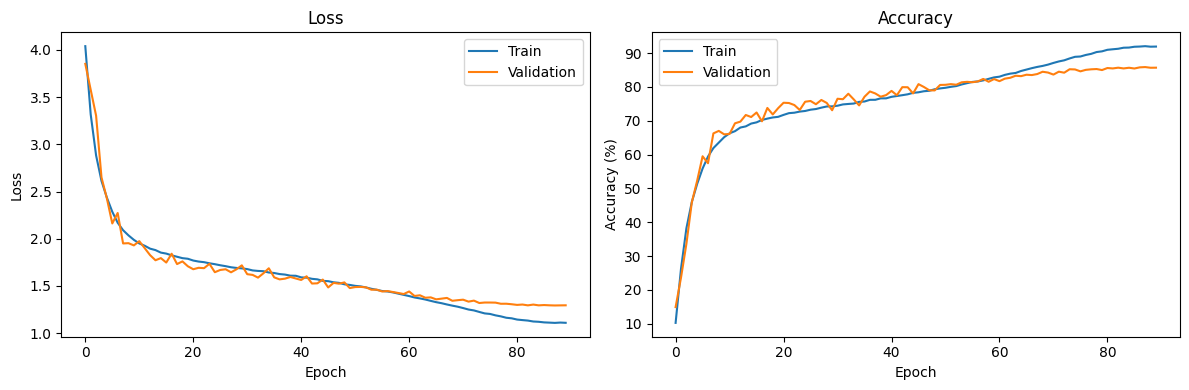

Training curves saved at plots/vgg16_imagenet100_training_curves.png


In [ ]:
# Tunable training defaults for ImageNet-100.
# LAMBDA controls optional individual-weight L1 regularization for fine-grained unstructured pruning.
EPOCHS = 90
LEARNING_RATE = 0.05
LAMBDA = 1e-6
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5
LOAD_PRETRAINED = False
RUN_TRAINING = True

model = VGG16BN(num_classes=NUM_CLASSES)

if LOAD_PRETRAINED and BEST_MODEL_PATH.exists():
    model = load_model(model, str(BEST_MODEL_PATH), device=DEFAULT_DEVICE)
elif LOAD_PRETRAINED:
    print(f"Requested LOAD_PRETRAINED=True, but checkpoint was not found: {BEST_MODEL_PATH}")

if RUN_TRAINING:
    model, training_history = train_model(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        LAMBDA=LAMBDA,
        device=DEFAULT_DEVICE,
        weight_decay=WEIGHT_DECAY,
        warmup_epochs=WARMUP_EPOCHS,
        best_model_path=BEST_MODEL_PATH,
    )
else:
    print("RUN_TRAINING=False; skipping training cell.")


## Fine-Grained Unstructured Pruning

This section reports individual-weight sparsity and applies global unstructured magnitude pruning across Conv2d and Linear weights. The default target is 90% zero weights without changing tensor shapes. Keep pruning masks active if you fine-tune the pruned model, then call `remove_pruning_reparam(...)` before saving, PTQ, or TVM export.


In [ ]:
def _iter_prunable_modules(model: nn.Module):
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            yield name, module


def plot_weight_magnitude_distribution(
    model: nn.Module,
    bins: int = 100,
    filename: str = str(PLOTS_DIR / "weight_magnitude_distribution.png"),
) -> None:
    """Plot absolute individual-weight magnitudes for Conv2d and Linear layers."""
    weights = []
    for _, module in _iter_prunable_modules(model):
        weights.append(module.weight.detach().abs().flatten().cpu().numpy())

    if not weights:
        print("No Conv2d or Linear weights found for individual weight magnitude plotting.")
        return

    values = np.concatenate(weights)
    Path(filename).parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=bins, color="tab:blue", alpha=0.75, edgecolor="black")
    plt.title("Individual Weight Magnitude Distribution")
    plt.xlabel("absolute weight value")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Individual weight magnitude distribution saved at {filename}")


def _tensor_zero_count(tensor: torch.Tensor) -> Tuple[int, int]:
    detached = tensor.detach()
    return int((detached == 0).sum().item()), detached.numel()


def report_model_sparsity(model: nn.Module) -> Dict[str, object]:
    """Report fine-grained unstructured sparsity over Conv2d and Linear weights."""
    total = 0
    zero = 0
    per_layer = []

    for name, module in _iter_prunable_modules(model):
        weight = module.weight.detach()
        layer_zero = int(torch.sum(weight == 0).item())
        layer_total = weight.numel()
        total += layer_total
        zero += layer_zero
        per_layer.append(
            {
                "layer": name,
                "zeros": layer_zero,
                "total": layer_total,
                "sparsity": layer_zero / max(layer_total, 1),
            }
        )

    sparsity = zero / max(total, 1)
    print(f"Fine-grained weight sparsity: {100.0 * sparsity:.2f}% ({zero:,}/{total:,})")
    for item in per_layer:
        print(
            f"  {item['layer']:<32} individual weight sparsity="
            f"{100.0 * item['sparsity']:.2f}% ({item['zeros']:,}/{item['total']:,})"
        )
    return {
        "total_parameters": total,
        "zero_parameters": zero,
        "zero_weight_ratio": sparsity,
        "global_sparsity": sparsity,
        "per_layer_sparsity": per_layer,
    }


def report_pruning_statistics(model: nn.Module, verbose: bool = True) -> Dict[str, object]:
    """Backward-compatible wrapper for fine-grained unstructured pruning statistics."""
    if verbose:
        return report_model_sparsity(model)

    total = 0
    zero = 0
    per_layer = []
    for name, module in _iter_prunable_modules(model):
        weight = module.weight.detach()
        layer_zero = int(torch.sum(weight == 0).item())
        layer_total = weight.numel()
        total += layer_total
        zero += layer_zero
        per_layer.append(
            {
                "layer": name,
                "zeros": layer_zero,
                "total": layer_total,
                "sparsity": layer_zero / max(layer_total, 1),
            }
        )
    sparsity = zero / max(total, 1)
    return {
        "total_parameters": total,
        "zero_parameters": zero,
        "zero_weight_ratio": sparsity,
        "global_sparsity": sparsity,
        "per_layer_sparsity": per_layer,
    }


def apply_global_unstructured_pruning(model: nn.Module, amount: float) -> None:
    """Apply global fine-grained unstructured L1 magnitude pruning to individual weights."""
    if not 0.0 <= amount < 1.0:
        raise ValueError("amount must be in [0.0, 1.0)")

    parameters_to_prune = []
    for _, module in _iter_prunable_modules(model):
        parameters_to_prune.append((module, "weight"))

    if not parameters_to_prune:
        raise ValueError("No Conv2d or Linear weights found for fine-grained unstructured pruning.")

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount,
    )


def remove_pruning_reparam(model: nn.Module) -> None:
    """Make active fine-grained pruning masks permanent before saving, PTQ, or export."""
    for _, module in _iter_prunable_modules(model):
        if hasattr(module, "weight_orig"):
            prune.remove(module, "weight")


Model loaded from weights/best_vgg16_imagenet100_pruned_ready.pth (59.14 MB)


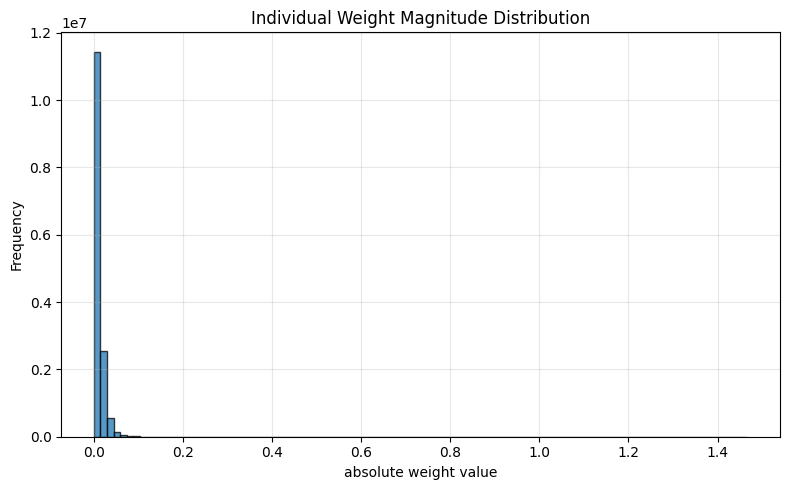

Individual weight magnitude distribution saved at plots/weight_magnitude_distribution.png
Baseline FP32 individual-weight sparsity before fine-grained unstructured pruning:
Fine-grained weight sparsity: 0.00% (0/14,761,664)
  features.0                       individual weight sparsity=0.00% (0/1,728)
  features.3                       individual weight sparsity=0.00% (0/36,864)
  features.7                       individual weight sparsity=0.00% (0/73,728)
  features.10                      individual weight sparsity=0.00% (0/147,456)
  features.14                      individual weight sparsity=0.00% (0/294,912)
  features.17                      individual weight sparsity=0.00% (0/589,824)
  features.20                      individual weight sparsity=0.00% (0/589,824)
  features.24                      individual weight sparsity=0.00% (0/1,179,648)
  features.27                      individual weight sparsity=0.00% (0/2,359,296)
  features.30                      individual weight spa

FP32 baseline test:   0%|          | 0/79 [00:00<?, ?it/s]

FP32 baseline accuracy: 85.86%
Applied global fine-grained unstructured pruning to 80.00% of Conv2d/Linear weights.
Pruned FP32 individual-weight sparsity with pruning masks active:
Fine-grained weight sparsity: 80.00% (11,809,331/14,761,664)
  features.0                       individual weight sparsity=23.21% (401/1,728)
  features.3                       individual weight sparsity=65.87% (24,282/36,864)
  features.7                       individual weight sparsity=52.92% (39,016/73,728)
  features.10                      individual weight sparsity=56.62% (83,483/147,456)
  features.14                      individual weight sparsity=61.67% (181,878/294,912)
  features.17                      individual weight sparsity=70.79% (417,558/589,824)
  features.20                      individual weight sparsity=67.12% (395,875/589,824)
  features.24                      individual weight sparsity=71.94% (848,683/1,179,648)
  features.27                      individual weight sparsity=81.91% (

Epoch 1/6:   0%|          | 0/2032 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 005/6 | Train Loss 1.1947 | Train Acc 89.66% | Val Loss 1.3200 | Val Acc 85.28%


Epoch 6/6:   0%|          | 0/2032 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 006/6 | Train Loss 1.1849 | Train Acc 90.02% | Val Loss 1.3140 | Val Acc 85.40%


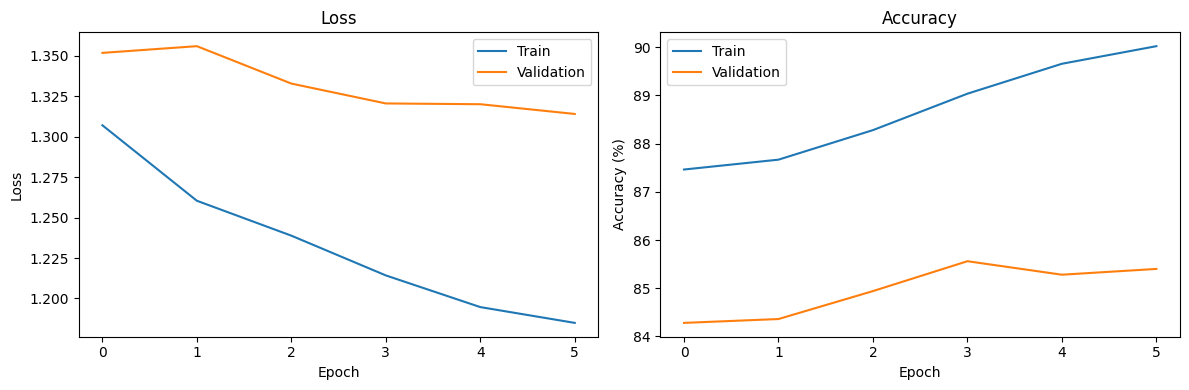

Training curves saved at plots/vgg16_imagenet100_training_curves.png
Pruned FP32 individual-weight sparsity after removing pruning reparameterization:
Fine-grained weight sparsity: 80.00% (11,809,331/14,761,664)
  features.0                       individual weight sparsity=23.21% (401/1,728)
  features.3                       individual weight sparsity=65.87% (24,282/36,864)
  features.7                       individual weight sparsity=52.92% (39,016/73,728)
  features.10                      individual weight sparsity=56.62% (83,483/147,456)
  features.14                      individual weight sparsity=61.67% (181,878/294,912)
  features.17                      individual weight sparsity=70.79% (417,558/589,824)
  features.20                      individual weight sparsity=67.12% (395,875/589,824)
  features.24                      individual weight sparsity=71.94% (848,683/1,179,648)
  features.27                      individual weight sparsity=81.91% (1,932,453/2,359,296)
  features

Pruned FP32 test:   0%|          | 0/79 [00:00<?, ?it/s]

Pruned FP32 accuracy: 85.40%
Model saved at weights/vgg16_imagenet100_pruned_fp32.pth (59.14 MB)


'weights/vgg16_imagenet100_pruned_fp32.pth'

In [ ]:
PRUNE_TARGET_SPARSITY = 0.80
LEARNING_RATE = 0.05
LAMBDA = 1e-6
WEIGHT_DECAY = 1e-4
RUN_PRUNING = True
FINE_TUNE_PRUNED_MODEL = True
PRUNED_FINE_TUNE_EPOCHS = 6
criterion_eval = nn.CrossEntropyLoss()

baseline_model = load_model(VGG16BN(num_classes=NUM_CLASSES), str(BEST_MODEL_PATH), device=DEFAULT_DEVICE)
plot_weight_magnitude_distribution(baseline_model)
print("Baseline FP32 individual-weight sparsity before fine-grained unstructured pruning:")
baseline_stats = report_model_sparsity(baseline_model)

baseline_loss, baseline_acc = evaluate(
    baseline_model,
    test_loader,
    criterion_eval,
    device=DEFAULT_DEVICE,
    description="FP32 baseline test",
)
print(f"FP32 baseline accuracy: {baseline_acc:.2f}%")

pruned_model = copy.deepcopy(baseline_model)
if RUN_PRUNING:
    apply_global_unstructured_pruning(pruned_model, amount=PRUNE_TARGET_SPARSITY)
    print(f"Applied global fine-grained unstructured pruning to {100.0 * PRUNE_TARGET_SPARSITY:.2f}% of Conv2d/Linear weights.")

print("Pruned FP32 individual-weight sparsity with pruning masks active:")
pruned_stats = report_model_sparsity(pruned_model)

if FINE_TUNE_PRUNED_MODEL:
    print("Fine-tuning the pruned model while keeping individual-weight pruning masks active.")
    pruned_model, pruned_finetune_history = train_model(
        pruned_model,
        train_loader,
        val_loader,
        epochs=PRUNED_FINE_TUNE_EPOCHS,
        lr=LEARNING_RATE * 0.1,
        LAMBDA=0.0,
        device=DEFAULT_DEVICE,
        weight_decay=WEIGHT_DECAY,
        warmup_epochs=1,
        best_model_path=PRUNED_FP32_PATH,
    )

remove_pruning_reparam(pruned_model)
print("Pruned FP32 individual-weight sparsity after removing pruning reparameterization:")
pruned_stats = report_model_sparsity(pruned_model)

pruned_loss, pruned_acc = evaluate(
    pruned_model,
    test_loader,
    criterion_eval,
    device=DEFAULT_DEVICE,
    description="Pruned FP32 test",
)
print(f"Pruned FP32 accuracy: {pruned_acc:.2f}%")
save_model(pruned_model, str(PRUNED_FP32_PATH), existed="overwrite")


## PTQ with Power-of-Two Observer

The custom observer rounds scales to the nearest power of two. PTQ runs on CPU using `fbgemm`: load the pruned FP32 checkpoint, fuse Conv-BN-ReLU blocks, attach the custom qconfig, prepare, calibrate on ImageNet-100 validation data, convert to INT8, evaluate, and save the quantized state dict.


In [ ]:
class PowerOfTwoObserver(tq.MinMaxObserver):
    """Min/max observer that rounds quantization scales to powers of two."""

    def __init__(self, *args, ema_decay: float = 0.95, **kwargs):
        super().__init__(*args, **kwargs)
        self.ema_decay = ema_decay
        self.register_buffer("moving_max_abs", torch.tensor(0.0))
        self.register_buffer("moving_initialized", torch.tensor(False))

    def forward(self, x_orig: torch.Tensor) -> torch.Tensor:
        super().forward(x_orig)
        with torch.no_grad():
            current_max_abs = x_orig.detach().abs().max().to(self.moving_max_abs.device)
            if not bool(self.moving_initialized.item()):
                self.moving_max_abs.copy_(current_max_abs)
                self.moving_initialized.fill_(True)
            else:
                self.moving_max_abs.mul_(self.ema_decay).add_(current_max_abs * (1.0 - self.ema_decay))
        return x_orig

    @staticmethod
    def scale_approximate(scale: float, min_exp: int = -32, max_exp: int = 16) -> float:
        if scale <= 0 or math.isnan(scale) or math.isinf(scale):
            return 1.0
        exponent = int(round(math.log2(scale)))
        exponent = max(min_exp, min(max_exp, exponent))
        return float(2.0 ** exponent)

    def calculate_qparams(self) -> Tuple[torch.Tensor, torch.Tensor]:
        device = self.min_val.device
        min_val = float(self.min_val.item())
        max_val = float(self.max_val.item())
        if any(math.isnan(v) or math.isinf(v) for v in (min_val, max_val)) or min_val == max_val:
            return torch.tensor([1.0], dtype=torch.float32, device=device), torch.tensor([0], dtype=torch.int64, device=device)

        quant_min = self.quant_min
        quant_max = self.quant_max
        if self.dtype == torch.qint8 and self.qscheme == torch.per_tensor_symmetric:
            max_abs = max(abs(min_val), abs(max_val))
            if bool(self.moving_initialized.item()):
                max_abs = max(max_abs, float(self.moving_max_abs.item()))
            scale = self.scale_approximate(max_abs / max(abs(quant_min), abs(quant_max), 1))
            zero_point = 0
        elif self.dtype == torch.quint8 and self.qscheme == torch.per_tensor_affine:
            scale = self.scale_approximate((max_val - min_val) / max(float(quant_max - quant_min), 1.0))
            zero_point = int(round(quant_min - min_val / scale))
            zero_point = max(quant_min, min(quant_max, zero_point))
        else:
            raise NotImplementedError(f"Unsupported dtype/qscheme: {self.dtype}, {self.qscheme}")

        return (
            torch.tensor([scale], dtype=torch.float32, device=device),
            torch.tensor([zero_point], dtype=torch.int64, device=device),
        )

    def extra_repr(self) -> str:
        return (
            f"min_val={self.min_val}, max_val={self.max_val}, "
            f"moving_max_abs={self.moving_max_abs}, ema_decay={self.ema_decay}, "
            f"dtype={self.dtype}, qscheme={self.qscheme}"
        )


POWER2_QCONFIG = tq.QConfig(
    activation=PowerOfTwoObserver.with_args(
        dtype=torch.quint8,
        qscheme=torch.per_tensor_affine,
        quant_min=0,
        quant_max=255,
        ema_decay=0.95,
    ),
    weight=PowerOfTwoObserver.with_args(
        dtype=torch.qint8,
        qscheme=torch.per_tensor_symmetric,
        quant_min=-127,
        quant_max=127,
        ema_decay=0.95,
    ),
)


def calibrate(model: nn.Module, loader: DataLoader, device: str = "cpu", max_batches: Optional[int] = 100) -> None:
    model.eval()
    model.to(device)
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(tqdm(loader, desc="Calibrating", leave=False)):
            if max_batches is not None and batch_idx >= max_batches:
                break
            model(images.to(device))


def prepare_fp32_model_for_ptq(fp32_checkpoint: str) -> nn.Module:
    model_fp32 = load_model(VGG16BN(num_classes=NUM_CLASSES), fp32_checkpoint, device="cpu")
    model_fp32.eval()
    model_fp32.fuse_model()
    model_fp32.qconfig = POWER2_QCONFIG
    return model_fp32


def ptq_quantization(
    fp32_checkpoint: str = str(PRUNED_FP32_PATH),
    calibration_loader: DataLoader = val_loader,
    save_path: str = str(PTQ_INT8_PATH),
    calibration_batches: Optional[int] = 100,
) -> nn.Module:
    torch.backends.quantized.engine = "fbgemm"
    model_fp32 = prepare_fp32_model_for_ptq(fp32_checkpoint)
    model_prepared = tq.prepare(model_fp32, inplace=False)
    calibrate(model_prepared, calibration_loader, device="cpu", max_batches=calibration_batches)
    model_int8 = tq.convert(model_prepared, inplace=False)
    model_int8.eval()
    save_model(model_int8, save_path, existed="overwrite")
    return model_int8


def load_quantized_model(filename: str = str(PTQ_INT8_PATH)) -> nn.Module:
    torch.backends.quantized.engine = "fbgemm"
    model_fp32 = prepare_fp32_model_for_ptq(str(PRUNED_FP32_PATH))
    prepared = tq.prepare(model_fp32, inplace=False)
    model_int8 = tq.convert(prepared, inplace=False)
    state_dict = torch.load(filename, map_location="cpu", weights_only=False)
    model_int8.load_state_dict(state_dict)
    model_int8.eval()
    return model_int8


In [ ]:
RUN_PTQ = True
CALIBRATION_BATCHES = 100  # Set to None to use the full validation loader.

if RUN_PTQ:
    model_int8 = ptq_quantization(
        fp32_checkpoint=str(PRUNED_FP32_PATH),
        calibration_loader=val_loader,
        save_path=str(PTQ_INT8_PATH),
        calibration_batches=CALIBRATION_BATCHES,
    )
    int8_loss, int8_acc = evaluate(
        model_int8,
        test_loader,
        criterion_eval,
        device="cpu",
        description="Power-of-two PTQ INT8 test",
    )
    print(f"PTQ INT8 accuracy: {int8_acc:.2f}%")
else:
    print("RUN_PTQ=False; skipping PTQ cell.")


Model loaded from weights/vgg16_imagenet100_pruned_fp32.pth (59.14 MB)


/tmp/ipykernel_371/1853027226.py:108: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = tq.prepare(model_fp32, inplace=False)


Calibrating:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipykernel_371/1853027226.py:110: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = tq.convert(model_prepared, inplace=False)


Model saved at weights/vgg16_imagenet100_pruned_power2_int8.pth (14.80 MB)


Power-of-two PTQ INT8 test:   0%|          | 0/79 [00:00<?, ?it/s]

PTQ INT8 accuracy: 85.12%


## Evaluation Comparison

This section compares the original FP32 checkpoint, the fine-grained unstructured pruned FP32 checkpoint, and the power-of-two PTQ INT8 checkpoint. It reports accuracy, individual-weight zero ratio, model size, and accuracy drops.


In [ ]:
def compare_models() -> Dict[str, float]:
    criterion = nn.CrossEntropyLoss()
    baseline = load_model(VGG16BN(num_classes=NUM_CLASSES), str(BEST_MODEL_PATH), device=DEFAULT_DEVICE, verbose=False)
    pruned = load_model(VGG16BN(num_classes=NUM_CLASSES), str(PRUNED_FP32_PATH), device=DEFAULT_DEVICE, verbose=False)

    _, baseline_acc_cmp = evaluate(baseline, test_loader, criterion, device=DEFAULT_DEVICE, description="Compare baseline")
    _, pruned_acc_cmp = evaluate(pruned, test_loader, criterion, device=DEFAULT_DEVICE, description="Compare pruned")

    int8_acc_cmp = float("nan")
    if PTQ_INT8_PATH.exists():
        quantized = load_quantized_model(str(PTQ_INT8_PATH))
        _, int8_acc_cmp = evaluate(quantized, test_loader, criterion, device="cpu", description="Compare INT8")
    else:
        print(f"Quantized checkpoint not found at {PTQ_INT8_PATH}; skipping INT8 comparison.")

    baseline_stats_cmp = report_pruning_statistics(baseline, verbose=False)
    pruned_stats_cmp = report_pruning_statistics(pruned, verbose=False)

    print("=" * 72)
    print(f"FP32 baseline accuracy: {baseline_acc_cmp:.2f}%")
    print(f"Pruned FP32 accuracy: {pruned_acc_cmp:.2f}%")
    if not math.isnan(int8_acc_cmp):
        print(f"PTQ INT8 accuracy: {int8_acc_cmp:.2f}%")
    print(f"Baseline parameter count: {baseline_stats_cmp['total_parameters']:,}")
    print(f"Pruned parameter count: {pruned_stats_cmp['total_parameters']:,}")
    print(f"Global individual-weight zero ratio: {pruned_stats_cmp['zero_weight_ratio']:.2%}")
    print(f"Baseline model size: {model_file_size_mb(str(BEST_MODEL_PATH)):.2f} MB")
    print(f"Pruned FP32 model size: {model_file_size_mb(str(PRUNED_FP32_PATH)):.2f} MB")
    print(f"PTQ INT8 model size: {model_file_size_mb(str(PTQ_INT8_PATH)):.2f} MB")
    print(f"Accuracy drop after fine-grained unstructured pruning: {baseline_acc_cmp - pruned_acc_cmp:.2f} percentage points")
    if not math.isnan(int8_acc_cmp):
        print(f"Accuracy drop after PTQ: {pruned_acc_cmp - int8_acc_cmp:.2f} percentage points")
    print("=" * 72)

    return {
        "baseline_acc": baseline_acc_cmp,
        "pruned_acc": pruned_acc_cmp,
        "int8_acc": int8_acc_cmp,
        "baseline_size_mb": model_file_size_mb(str(BEST_MODEL_PATH)),
        "pruned_size_mb": model_file_size_mb(str(PRUNED_FP32_PATH)),
        "int8_size_mb": model_file_size_mb(str(PTQ_INT8_PATH)),
        "zero_weight_ratio": pruned_stats_cmp["zero_weight_ratio"],
    }


comparison_metrics = compare_models()


Compare baseline:   0%|          | 0/79 [00:00<?, ?it/s]

Compare pruned:   0%|          | 0/79 [00:00<?, ?it/s]

Model loaded from weights/vgg16_imagenet100_pruned_fp32.pth (59.14 MB)


/tmp/ipykernel_371/1853027226.py:119: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = tq.prepare(model_fp32, inplace=False)
/tmp/ipykernel_371/1853027226.py:120: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize

Compare INT8:   0%|          | 0/79 [00:00<?, ?it/s]

FP32 baseline accuracy: 85.86%
Pruned FP32 accuracy: 85.40%
PTQ INT8 accuracy: 85.12%
Baseline parameter count: 14,761,664
Pruned parameter count: 14,761,664
Global individual-weight zero ratio: 80.00%
Baseline model size: 59.14 MB
Pruned FP32 model size: 59.14 MB
PTQ INT8 model size: 14.80 MB
Accuracy drop after fine-grained unstructured pruning: 0.46 percentage points
Accuracy drop after PTQ: 0.28 percentage points


In [ ]:
# 確保模型已載入
if 'model_int8' not in locals():
    model_int8 = load_quantized_model(str(PTQ_INT8_PATH))

# 想查看的 layer 與 output channel
target_layer_name = 'features.3'
target_channel_idx = 60

found = False

for name, module in model_int8.named_modules():

    if name == target_layer_name:

        if hasattr(module, 'weight'):

            # Quantized weight tensor
            q_weight = module.weight()

            print(f"--- Layer: {target_layer_name} ---")
            print(f"Weight Shape: {q_weight.shape}")
            print(f"Dtype: {q_weight.dtype}")

            # 查看 quantization 參數
            print("\n=== Quantization Parameters ===")

            if q_weight.qscheme() in (
                torch.per_channel_affine,
                torch.per_channel_symmetric
            ):

                print("QScheme: Per-Channel")

                scales = q_weight.q_per_channel_scales()
                zero_points = q_weight.q_per_channel_zero_points()

                print(f"Scale[{target_channel_idx}]: {scales[target_channel_idx]}")
                print(f"ZeroPoint[{target_channel_idx}]: {zero_points[target_channel_idx]}")

            else:

                print("QScheme: Per-Tensor")
                print(f"Scale: {q_weight.q_scale()}")
                print(f"ZeroPoint: {q_weight.q_zero_point()}")

            print("\n=== INT8 Raw Weight Values ===")

            # 真正 INT8 integer values
            int8_weight = q_weight.int_repr()

            print(f"INT8 Weight Shape: {int8_weight.shape}")

            # 顯示特定 output channel 的 INT8 權重
            display(int8_weight[target_channel_idx])

            # print("\n=== Dequantized Float Values ===")

            # # 對照用 float
            # display(q_weight[target_channel_idx])

            # 統計 sparsity
            total = int8_weight.numel()
            zero = (int8_weight == 0).sum().item()

            print("\n=== Sparsity Statistics ===")
            print(f"Zero Weights: {zero}")
            print(f"Total Weights: {total}")
            print(f"Sparsity: {100.0 * zero / total:.2f}%")

            found = True
            break

if not found:
    print(f"Layer '{target_layer_name}' not found.")

--- Layer: features.3 ---
Weight Shape: torch.Size([64, 64, 3, 3])
Dtype: torch.qint8

=== Quantization Parameters ===
QScheme: Per-Tensor
Scale: 0.001953125
ZeroPoint: 0

=== INT8 Raw Weight Values ===
INT8 Weight Shape: torch.Size([64, 64, 3, 3])


tensor([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [ 11,  14,  16]],

        [[  0,  10,   0],
         [  0,  12,  10],
         [  0,  11,  13]],

        [[  0,  -8,  -8],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[  0,   0,   0],
         [  0,  -9,  -9],
         [  0,   0,   0]],

        [[-18, -12,   0],
         [-14,   0,   0],
         [-10,  -7,  -6]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[ 15,   0, -10],
         [-10,   0,  -6],
         [ -4,  21,   0]],

        [[ -7, -11, -10],
         [ -7,  -6,  -9],
         [ -9,  -7,  -7]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[-16,   0,   8],
         [  0,   0,   0],
         [  0,   0,  -8]],

        [[  0,   0,   0],
         [  0,


=== Sparsity Statistics ===
Zero Weights: 24283
Total Weights: 36864
Sparsity: 65.87%
